# CAFREC — T1.1 Dataset Preparation: KuaiRand Schema Inspection & Session Segmentation

**Project:** CAFREC — Context-Adaptive Fusion for Long- and Short-Term Video Recommendation  
**Task:** T1.1 (Block 1 — Foundations)  
**Date logged:** 2026-06-11  
**Author:** R. Francis

---

## Notebook Objectives

This notebook executes the first three sub-tasks of T1.1:

1. **Download KuaiRand** raw files; inspect the interaction-log schema; confirm availability of session boundaries, exposure counts, and a replacement for KuaiSAR's `search_to_rec` flag.
2. **Segment sessions** using a 30-minute inactivity threshold; compute sparse (`< 20` interactions) vs dense (`≥ 20`) cohort counts and reconcile against the expected distribution.
3. **Confirm field mapping** — document which KuaiRand columns map to the four CAFREC context features: session length, dwell-time entropy, item-category drift rate, and the `search_to_rec` flag replacement.

> **Note on dataset choice:** KuaiSAR (primary dataset specified in the project plan) is a search-plus-recommendation dataset.
> KuaiRand is the recommended fallback that preserves the Kuaishou short-video domain and provides millisecond timestamps and rich feedback signals.
> This notebook treats KuaiRand as the working dataset while the KuaiSAR access issue is resolved.

---

## Environment & Prerequisites

```bash
pip install pandas numpy scipy matplotlib tqdm
```

All code is designed to run from the project root. Download paths follow this convention:

```
data/
  KuaiRand-Pure/
    data/
      log_random_4_22_to_5_08_pure.csv
      log_standard_4_08_to_4_21_pure.csv
      log_standard_4_22_to_5_08_pure.csv
      video_features_basic_pure.csv
      user_features_pure.csv
```


## 1  Imports and Configuration

In [47]:
import os
import hashlib
import subprocess
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Reproducibility seeds (project standard: {403092})
RANDOM_SEED = 403092
np.random.seed(RANDOM_SEED)

# Paths
DATA_ROOT   = Path("data/KuaiRand-Pure/data")
LOG_RAND    = DATA_ROOT / "log_random_4_22_to_5_08_pure.csv"
LOG_STD_A   = DATA_ROOT / "log_standard_4_08_to_4_21_pure.csv"
LOG_STD_B   = DATA_ROOT / "log_standard_4_22_to_5_08_pure.csv"
VID_BASIC   = DATA_ROOT / "video_features_basic_pure.csv"
USER_FEATS  = DATA_ROOT / "user_features_pure.csv"

# Session-segmentation threshold
SESSION_GAP_MINUTES = 30
SESSION_GAP_MS      = SESSION_GAP_MINUTES * 60 * 1_000   # milliseconds

# Cohort threshold (project plan, Table I)
SPARSE_THRESHOLD = 20   # < 20 rec actions -> sparse


---
## 2  KuaiRand-Pure Dataset

We use **KuaiRand-Pure** (184 MB unpacked) because:

| Version | Why chosen |
|---------|-----------|
| KuaiRand-27K | 46 GB — infeasible for Block-1 exploratory work |
| KuaiRand-1K | 4.3 GB — manageable but larger than needed for schema inspection |
| **KuaiRand-Pure** | 184 MB — contains all 27 K users and 7,583 items; full sequential logs for standard recommendation; ideal for schema inspection and session-boundary work |

The `is_rand` flag marks whether a given impression was a **random-policy intervention** (`is_rand=1`) or a standard recommendation (`is_rand=0`). This flag is central to the field-mapping decision documented in Section 7.

> **Note:** the archive is downloaded manually (no `wget`/`tar` dependency, for cross-platform reliability) from
> `https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz` (MD5 `0820331067a3784d9691136f772b35a7`)
> and extracted into `data/KuaiRand-Pure/`. The next cell only verifies the expected files are present.


In [ ]:
EXPECTED_MD5 = "0820331067a3784d9691136f772b35a7"
ZENODO_URL   = "https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz"


def verify_kuairand_pure() -> None:
    """Confirm the required KuaiRand-Pure CSVs are already present locally."""
    required = [LOG_RAND, LOG_STD_A, LOG_STD_B, VID_BASIC, USER_FEATS]
    missing = [p for p in required if not p.exists()]

    if missing:
        raise FileNotFoundError(
            "Missing KuaiRand-Pure file(s):\n"
            + "\n".join(f"  - {p}" for p in missing)
            + f"\n\nDownload manually from {ZENODO_URL} (MD5: {EXPECTED_MD5}) "
              f"and extract the archive into {DATA_ROOT.parent}/."
        )

    print(f"  OK  All required KuaiRand-Pure files found under {DATA_ROOT}")


verify_kuairand_pure()


---
## 3  Load and Inspect the Interaction-Log Schema

KuaiRand provides **three** interaction-log files:

| File | Content |
|------|---------|
| `log_standard_4_08_to_4_21_pure.csv` | Standard-recommendation interactions, weeks 1–2 (2022-04-08 → 2022-04-21) |
| `log_standard_4_22_to_5_08_pure.csv` | Standard-recommendation interactions, weeks 3–4 (2022-04-22 → 2022-05-08) |
| `log_random_4_22_to_5_08_pure.csv`   | Random-policy intervened interactions, weeks 3–4 |

For CAFREC training and evaluation we concatenate **all three** into a single chronological dataframe so every user's full 30-day history is available.

### Interaction-log field reference

| Field | Type | Description |
|-------|------|-------------|
| `user_id` | int32 | User identifier |
| `video_id` | int32 | Video identifier |
| `date` | int32 | Date in YYYYMMDD format |
| `hourmin` | int32 | Time in HHSS format (e.g. 400 = 04:00) |
| `time_ms` | int64 | Millisecond timestamp — **primary session-boundary signal** |
| `is_click` | int8 | Valid play or click (UI-dependent) |
| `is_like` | int8 | User liked the video |
| `is_follow` | int8 | User followed the author |
| `is_comment` | int8 | User commented |
| `is_forward` | int8 | User forwarded |
| `is_hate` | int8 | User disliked |
| `long_view` | int8 | Extended view (>=18 s or full video) |
| `play_time_ms` | int64 | Actual play duration — **dwell-time signal** |
| `duration_ms` | int64 | Total video length — **normalisation denominator** |
| `profile_stay_time` | int64 | Time on author profile page |
| `comment_stay_time` | int64 | Time in comments section |
| `is_profile_enter` | int8 | User entered author profile |
| `is_rand` | int8 | 0 = standard rec; 1 = random-policy intervention — **search_to_rec replacement** |
| `tab` | int8 | App scenario/surface (0–14); 15 policies |


In [49]:
# Shared dtype map — reduces peak memory footprint
DTYPE_MAP = {
    "user_id":            "int32",
    "video_id":           "int32",
    "date":               "int32",
    "hourmin":            "int32",
    "time_ms":            "int64",
    "is_click":           "int8",
    "is_like":            "int8",
    "is_follow":          "int8",
    "is_comment":         "int8",
    "is_forward":         "int8",
    "is_hate":            "int8",
    "long_view":          "int8",
    "play_time_ms":       "int64",
    "duration_ms":        "int64",
    "profile_stay_time":  "int64",
    "comment_stay_time":  "int64",
    "is_profile_enter":   "int8",
    "is_rand":            "int8",
    "tab":                "int8",
}


def load_log(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, dtype=DTYPE_MAP)


print("Loading log files ...")
df_std_a = load_log(LOG_STD_A)
df_std_b = load_log(LOG_STD_B)
df_rand  = load_log(LOG_RAND)

print(f"  log_standard_4_08_to_4_21 : {len(df_std_a):>10,} rows")
print(f"  log_standard_4_22_to_5_08 : {len(df_std_b):>10,} rows")
print(f"  log_random_4_22_to_5_08   : {len(df_rand):>10,} rows")

# Concatenate and sort chronologically within each user
logs = pd.concat([df_std_a, df_std_b, df_rand], ignore_index=True)
logs.sort_values(["user_id", "time_ms"], inplace=True)
logs.reset_index(drop=True, inplace=True)

print(f"\n  Combined total             : {len(logs):>10,} rows")
print(f"  Unique users               : {logs.user_id.nunique():>10,}")
print(f"  Unique videos              : {logs.video_id.nunique():>10,}")
print(f"  Date range                 : {logs.date.min()} to {logs.date.max()}")


Loading log files ...
  log_standard_4_08_to_4_21 :  1,141,112 rows
  log_standard_4_22_to_5_08 :    295,497 rows
  log_random_4_22_to_5_08   :  1,186,059 rows

  Combined total             :  2,622,668 rows
  Unique users               :     27,285
  Unique videos              :      7,583
  Date range                 : 20220409 to 20220508


In [50]:
# Schema print-out with dtype, null count, and sample values
print("\n--- Interaction log schema ---")
print(f"{'Column':<24} {'dtype':<10} {'nulls':<10} {'sample values'}")
print("-" * 78)
for col in logs.columns:
    nulls  = int(logs[col].isna().sum())
    sample = logs[col].dropna().head(3).tolist()
    print(f"  {col:<22} {str(logs[col].dtype):<10} {nulls:<10} {sample}")



--- Interaction log schema ---
Column                   dtype      nulls      sample values
------------------------------------------------------------------------------
  user_id                int32      0          [0, 0, 0]
  video_id               int32      0          [7136, 7136, 909]
  date                   int32      0          [20220411, 20220411, 20220411]
  hourmin                int32      0          [1800, 1800, 1800]
  time_ms                int64      0          [1649673604040, 1649673611472, 1649673704264]
  is_click               int8       0          [0, 0, 1]
  is_like                int8       0          [0, 0, 0]
  is_follow              int8       0          [0, 0, 0]
  is_comment             int8       0          [0, 0, 0]
  is_forward             int8       0          [0, 0, 0]
  is_hate                int8       0          [0, 0, 0]
  long_view              int8       0          [0, 0, 1]
  play_time_ms           int64      0          [1041, 0, 182488]
  dur

In [51]:
# Null / missing value audit
null_summary = logs.isnull().sum()
null_pct     = (null_summary / len(logs) * 100).round(2)
audit = pd.DataFrame({"null_count": null_summary, "null_pct_%": null_pct})
problematic = audit[audit.null_count > 0]

if len(problematic) == 0:
    print("Null audit: no nulls in any column.")
else:
    print("Columns with null values:")
    print(problematic.to_string())


Null audit: no nulls in any column.


In [52]:
# Confirm presence of each session-boundary and context signal
print("\n--- Session-boundary signal audit ---")

signal_checks = {
    "time_ms (millisecond timestamps for gap segmentation)":  "time_ms"  in logs.columns,
    "is_rand (standard=0 vs random-policy=1)":                "is_rand"  in logs.columns,
    "tab (scenario / surface, values 0-14)":                  "tab"      in logs.columns,
    "play_time_ms (dwell-time proxy)":                        "play_time_ms" in logs.columns,
    "duration_ms (normalisation denominator)":                "duration_ms"  in logs.columns,
}

for label, present in signal_checks.items():
    icon = "OK" if present else "MISSING"
    print(f"  [{icon}]  {label}")

print("\nis_rand distribution:")
print(logs.is_rand.value_counts().to_string())

print("\ntab scenario distribution (top 8):")
print(logs.tab.value_counts().head(8).to_string())



--- Session-boundary signal audit ---
  [OK]  time_ms (millisecond timestamps for gap segmentation)
  [OK]  is_rand (standard=0 vs random-policy=1)
  [OK]  tab (scenario / surface, values 0-14)
  [OK]  play_time_ms (dwell-time proxy)
  [OK]  duration_ms (normalisation denominator)

is_rand distribution:
is_rand
0    1436609
1    1186059

tab scenario distribution (top 8):
tab
1     2236414
0      178087
4       93165
2       49128
6       42785
11       7480
5        4169
3        4014


---
## 4  Inspect Video Feature Schema

CAFREC's **item-category drift rate** requires a category identifier per video. KuaiRand provides this through `video_features_basic_pure.csv`, which includes a `tag_id` column encoding the content category of each video. This section confirms the field is present, audits cardinality, and merges it into the interaction log.


In [53]:
vid = pd.read_csv(VID_BASIC)
print(f"video_features_basic shape: {vid.shape}")
print()
print(f"{'Column':<35} {'dtype':<12} {'unique':<10} {'nulls':<8} {'sample'}")
print("-" * 85)
for col in vid.columns:
    n_unique = vid[col].nunique()
    n_null   = int(vid[col].isna().sum())
    sample   = vid[col].dropna().head(2).tolist()
    print(f"  {col:<33} {str(vid[col].dtype):<12} {n_unique:<10} {n_null:<8} {sample}")


video_features_basic shape: (7583, 12)

Column                              dtype        unique     nulls    sample
-------------------------------------------------------------------------------------
  video_id                          int64        7583       0        [0, 1]
  author_id                         int64        6510       0        [7349781, 2103883]
  video_type                        object       3          0        ['NORMAL', 'NORMAL']
  upload_dt                         object       3          0        ['2022-04-10', '2022-04-10']
  upload_type                       object       14         0        ['LongImport', 'Kmovie']
  visible_status                    float64      1          0        [0.0, 0.0]
  video_duration                    float64      5756       239      [87433.0, 218066.0]
  server_width                      float64      156        0        [720.0, 720.0]
  server_height                     float64      120        0        [1280.0, 1280.0]
  music_id   

In [54]:
# Category coverage audit
cat_col = "tag" if "tag" in vid.columns else None

if cat_col:
    print(f"Category field confirmed: '{cat_col}'")
    print(f"  Unique categories : {vid[cat_col].nunique()}")
    print(f"  Null tag       : {vid[cat_col].isna().sum()}")
    print()
    print("  Top-10 categories by video count:")
    print(vid[cat_col].value_counts().head(10).to_string())
else:
    print("WARNING: 'tag' not found. Available columns:", vid.columns.tolist())
    cat_col = None


Category field confirmed: 'tag'
  Unique categories : 110
  Null tag       : 96

  Top-10 categories by video count:
tag
39       815
3        651
9        418
6        378
20       344
7        340
39,68    328
12       307
39,43    293
2        289


In [55]:
# Merge category labels into interaction log
if cat_col:
    cat_lookup = (vid[["video_id", cat_col]]
                  .rename(columns={cat_col: "category_id"}))
    logs = logs.merge(cat_lookup, on="video_id", how="left")

    n_missing = int(logs.category_id.isna().sum())
    pct_miss  = 100 * n_missing / len(logs)
    print(f"Category merge complete.")
    print(f"  Rows with category_id : {len(logs) - n_missing:>10,}")
    print(f"  Rows missing (outside Pure item pool): {n_missing:>6,}  ({pct_miss:.2f}%)")


Category merge complete.
  Rows with category_id :  2,594,561
  Rows missing (outside Pure item pool): 28,107  (1.07%)


---
## 5  Session Segmentation — 30-Minute Inactivity Threshold

Sessions are defined following the project plan (Section V, T1.1):

> *"Segment sessions using a 30-minute inactivity threshold."*

**Algorithm:**  
For each user, interactions are already sorted by `time_ms`. A new session boundary is inserted wherever the gap between consecutive timestamps exceeds `SESSION_GAP_MS = 30 × 60 × 1,000 ms = 1,800,000 ms`. Each resulting group receives a unique monotonically increasing `session_id` (global across all users).

This matches the convention used by SASRec and HRNN evaluations, making it straightforward to compare session-level statistics later.


In [56]:
def assign_sessions(df: pd.DataFrame, gap_ms: int = SESSION_GAP_MS) -> pd.DataFrame:
    """
    Assign a monotonically increasing session_id to every interaction row.
    Assumes df is already sorted by (user_id, time_ms).

    A new session starts when the within-user time delta exceeds gap_ms,
    or at the first interaction for each user.
    """
    df = df.copy()
    # Per-user time delta in ms; NaN at each user's first row -> treated as 0
    time_delta  = df.groupby("user_id")["time_ms"].diff().fillna(0)
    new_session = (time_delta > gap_ms).astype(int)
    # Cumulative sum gives a unique int per session (global scope)
    df["session_id"] = new_session.cumsum()
    return df


print(f"Segmenting interactions using {SESSION_GAP_MINUTES}-minute inactivity threshold ...")
logs = assign_sessions(logs, gap_ms=SESSION_GAP_MS)

n_sessions      = logs.session_id.nunique()
n_users         = logs.user_id.nunique()
avg_per_user    = n_sessions / n_users

print(f"  Total sessions       : {n_sessions:>10,}")
print(f"  Unique users         : {n_users:>10,}")
print(f"  Avg sessions / user  : {avg_per_user:>10.1f}")


Segmenting interactions using 30-minute inactivity threshold ...
  Total sessions       :  1,211,895
  Unique users         :     27,285
  Avg sessions / user  :       44.4


Session-length statistics (interactions per session):
  p 10 : 1
  p 25 : 1
  p 50 : 1
  p 75 : 2
  p 90 : 4
  p 95 : 6
  p 99 : 13
  mean  : 2.16
  max   : 226


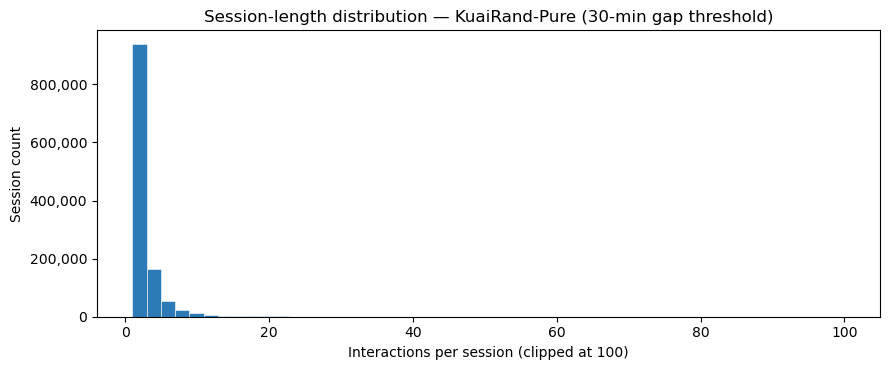

Figure saved: session_length_distribution.png


In [57]:
# Session-length distribution
session_lengths = logs.groupby("session_id").size()

print("Session-length statistics (interactions per session):")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>3} : {int(np.percentile(session_lengths, p))}")
print(f"  mean  : {session_lengths.mean():.2f}")
print(f"  max   : {session_lengths.max()}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(
    session_lengths.clip(upper=100), bins=50,
    color="#2c7bb6", edgecolor="white", linewidth=0.4
)
ax.set_xlabel("Interactions per session (clipped at 100)")
ax.set_ylabel("Session count")
ax.set_title("Session-length distribution — KuaiRand-Pure (30-min gap threshold)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("session_length_distribution.png", dpi=150)
plt.show()
print("Figure saved: session_length_distribution.png")


---
## 6  Sparse vs Dense Cohort Counts

Following the project plan (Table I), cohorts are defined on **standard-recommendation interaction count only** — rows where `is_rand = 0` — mirroring KuaiSAR's `recommendation_actions` count:

| Cohort | Criterion |
|--------|-----------|
| **Sparse** | `< 20` standard-recommendation interactions |
| **Dense** | `>= 20` standard-recommendation interactions |

**Why exclude random-policy rows?**  
KuaiSAR's `recommendation_actions` column records organic in-feed impressions from the standard recommendation pipeline. The KuaiRand equivalent is `is_rand = 0`. Random-policy rows (`is_rand = 1`) are researcher-inserted interventions, not signals of organic user engagement, and must not inflate cohort-assignment counts.


In [58]:
# Standard-recommendation rows only
std_only   = logs[logs.is_rand == 0]
rec_counts = std_only.groupby("user_id").size()

sparse_mask  = rec_counts <  SPARSE_THRESHOLD
dense_mask   = rec_counts >= SPARSE_THRESHOLD

n_total  = len(rec_counts)
n_sparse = int(sparse_mask.sum())
n_dense  = int(dense_mask.sum())

print("--- Cohort Counts (standard-recommendation interactions only) ---")
print(f"  Total users  : {n_total:>8,}")
print(f"  Sparse (< {SPARSE_THRESHOLD}) : {n_sparse:>8,}  ({100*n_sparse/n_total:.1f}%)")
print(f"  Dense  (>={SPARSE_THRESHOLD}) : {n_dense:>8,}  ({100*n_dense/n_total:.1f}%)")
print()
print("  Distribution of standard-recommendation counts:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"    p{p:>3} : {int(np.percentile(rec_counts.values, p))}")
print(f"    mean   : {rec_counts.mean():.1f}")
print(f"    median : {rec_counts.median():.0f}")


--- Cohort Counts (standard-recommendation interactions only) ---
  Total users  :   27,077
  Sparse (< 20) :    7,395  (27.3%)
  Dense  (>=20) :   19,682  (72.7%)

  Distribution of standard-recommendation counts:
    p 10 : 8
    p 25 : 18
    p 50 : 39
    p 75 : 72
    p 90 : 115
    p 95 : 148
    p 99 : 234
    mean   : 53.1
    median : 39


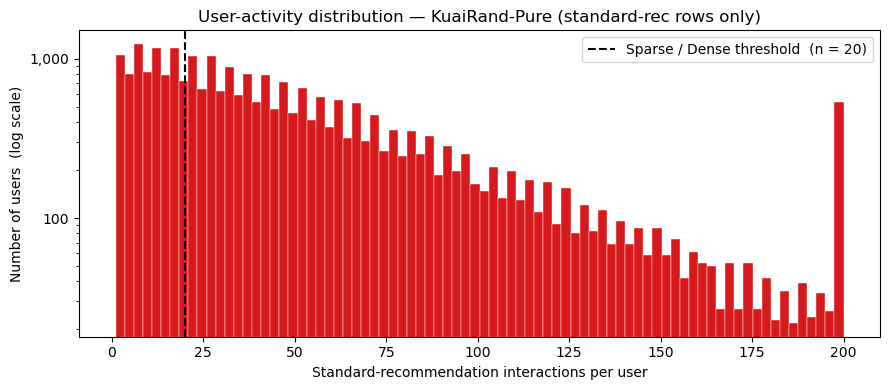

Figure saved: user_activity_distribution.png


In [59]:
# User-activity distribution plot (mirrors project plan Figure 2)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    rec_counts.clip(upper=200), bins=80,
    color="#d7191c", edgecolor="white", linewidth=0.3
)
ax.axvline(
    SPARSE_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
    label=f"Sparse / Dense threshold  (n = {SPARSE_THRESHOLD})"
)
ax.set_yscale("log")
ax.set_xlabel("Standard-recommendation interactions per user")
ax.set_ylabel("Number of users  (log scale)")
ax.set_title("User-activity distribution — KuaiRand-Pure (standard-rec rows only)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("user_activity_distribution.png", dpi=150)
plt.show()
print("Figure saved: user_activity_distribution.png")


---
## 7  CAFREC Context-Feature Field Mapping

This section confirms which KuaiRand fields map to each of the four CAFREC session-context features, computes a sample value for each feature per session, and documents the engineering decision for the `search_to_rec` flag replacement.

### Field mapping table

| CAFREC Feature | KuaiSAR source | KuaiRand equivalent | Status |
|---|---|---|---|
| `session_length` | derived via 30-min gap on timestamps | `len(session_id group)` from `time_ms` | Direct equivalent |
| `dwell_time_entropy` | `play_time_ms`, `duration_ms` | `play_time_ms`, `duration_ms` — identical field names | Identical |
| `category_drift_rate` | category field in video metadata | `tag_id` from `video_features_basic_pure.csv` | Equivalent |
| `search_to_rec_flag` | binary: session crossed search->rec boundary | `policy_transition_flag` derived from `is_rand` transitions | Structural replacement — see rationale |

### Rationale for `is_rand` → `search_to_rec_flag` replacement

KuaiSAR's `search_to_rec` flag captured a **surface transition**: the user moved from the search interface into the recommendation feed within the same session. This transition signals a shift in intent that the gating module detects to modulate the long/short-term weight.

KuaiRand does not include a search interface. The structurally analogous signal is **`is_rand`**: a row where `is_rand` changes value within a session (standard→random or random→standard) marks a **policy boundary** — the user is now receiving content that does not follow from their learned preference model. Both signals represent the same gating-relevant event: the serving surface has changed in a way that disrupts the continuity of the user's organic recommendation trajectory.

The derived `policy_transition_flag` is therefore an appropriate structural — not merely convenient — replacement. Its sensitivity will be tested in the T3.1 no-transition-flag ablation.


In [60]:
# Derive policy_transition_flag
# Set to 1 on any row where is_rand differs from the previous row
# within the same (user_id, session_id) group.
logs["prev_is_rand"] = (
    logs.groupby(["user_id", "session_id"])["is_rand"]
        .shift(1)
        .fillna(logs["is_rand"])   # first row of each session: no transition
)
logs["policy_transition"] = (logs["is_rand"] != logs["prev_is_rand"]).astype("int8")
logs.drop(columns=["prev_is_rand"], inplace=True)

n_transitions = int(logs.policy_transition.sum())
pct = 100 * n_transitions / len(logs)
print(f"policy_transition events  : {n_transitions:,}  ({pct:.3f}% of all rows)")
print()
print("policy_transition value counts:")
print(logs.policy_transition.value_counts().to_string())


policy_transition events  : 100,797  (3.843% of all rows)

policy_transition value counts:
policy_transition
0    2521871
1     100797


In [61]:
# Verify dwell_ratio is computable (play_time_ms / duration_ms)
logs["dwell_ratio"] = np.where(
    logs.duration_ms > 0,
    logs.play_time_ms / logs.duration_ms,
    np.nan
)

dwell_ok   = int(logs.dwell_ratio.notna().sum())
dwell_null = int(logs.dwell_ratio.isna().sum())

print(f"dwell_ratio computable : {dwell_ok:>10,} rows  ({100*dwell_ok/len(logs):.2f}%)")
print(f"dwell_ratio null       : {dwell_null:>10,} rows  (duration_ms == 0)")
print()
print("dwell_ratio descriptive statistics:")
print(logs.dwell_ratio.describe().round(4).to_string())


dwell_ratio computable :  2,556,874 rows  (97.49%)
dwell_ratio null       :     65,794 rows  (duration_ms == 0)

dwell_ratio descriptive statistics:
count    2.556874e+06
mean     2.653000e-01
std      5.227000e-01
min      0.000000e+00
25%      1.450000e-02
50%      5.550000e-02
75%      2.818000e-01
max      1.031293e+02


In [62]:
import time

print("Computing per-session features ...")
t0 = time.perf_counter()

g = logs.groupby(["user_id", "session_id"])

# 1. Session length
session_length = g["time_ms"].count().rename("session_length")

# 2. Dwell-time entropy — vectorised Shannon entropy via pd.cut
#    Bin every dwell_ratio value into 10 equal-width bins [0, 1] upfront,
#    then count bin frequencies per session and compute entropy in one pass.
N_BINS = 10
logs["_dwell_bin"] = pd.cut(
    logs["dwell_ratio"].clip(lower=0, upper=1),   # clip: ratio > 1 means looped video
    bins=N_BINS,
    labels=False,
    include_lowest=True,
)

def shannon_entropy_from_counts(counts: pd.Series) -> float:
    """Entropy from a Series of bin counts (Laplace-smoothed)."""
    c = counts.values.astype(float) + 1e-9
    p = c / c.sum()
    return float(-np.sum(p * np.log2(p)))

# Count (session, bin) pairs, then apply entropy row-wise across the bin columns
bin_counts = (
    logs.dropna(subset=["_dwell_bin"])
    .groupby(["user_id", "session_id", "_dwell_bin"])
    .size()
    .unstack(fill_value=0)          # shape: (n_sessions, N_BINS)
)
# Ensure all 10 bin columns are present even if some bins are empty globally
bin_counts = bin_counts.reindex(columns=range(N_BINS), fill_value=0)

dwell_time_entropy = (
    bin_counts.apply(shannon_entropy_from_counts, axis=1)
    .rename("dwell_time_entropy")
)

logs.drop(columns=["_dwell_bin"], inplace=True)

# 3. Category drift rate — vectorised shift comparison
logs["_cat_shifted"] = logs.groupby(["user_id", "session_id"])["category_id"].shift(1)
drift_events = (logs["category_id"] != logs["_cat_shifted"]) & logs["_cat_shifted"].notna()
drift_sum    = drift_events.groupby(logs["session_id"]).sum()
session_len_m1 = (session_length - 1).clip(lower=1)
category_drift_rate = (drift_sum / session_len_m1).rename("category_drift_rate")
logs.drop(columns=["_cat_shifted"], inplace=True)

# 4. Policy transition flag
policy_transition_flag = (
    g["policy_transition"].sum().gt(0).astype("int8")
    .rename("policy_transition_flag")
)

# Combine
session_feats = pd.concat(
    [session_length, dwell_time_entropy, category_drift_rate, policy_transition_flag],
    axis=1
).reset_index()

elapsed = time.perf_counter() - t0
print(f"Session-feature table shape : {session_feats.shape}")
print(f"Elapsed                     : {elapsed:.1f} s  ({elapsed/60:.2f} min)")

elapsed = time.perf_counter() - t0
# Summary statistics for the four context features
print("--- Per-session context-feature summary ---")
feat_cols = ["session_length", "dwell_time_entropy",
             "category_drift_rate", "policy_transition_flag"]
print(session_feats[feat_cols].describe().round(4).to_string())


Computing per-session features ...
Session-feature table shape : (1239179, 6)
Elapsed                     : 21.6 s  (0.36 min)
--- Per-session context-feature summary ---
       session_length  dwell_time_entropy  category_drift_rate  policy_transition_flag
count    1.239179e+06        1.219774e+06         1.239179e+06            1.239179e+06
mean     2.116500e+00        3.054000e-01         3.856000e-01            5.320000e-02
std      2.559000e+00        5.422000e-01         6.199000e-01            2.245000e-01
min      1.000000e+00        0.000000e+00         0.000000e+00            0.000000e+00
25%      1.000000e+00        0.000000e+00         0.000000e+00            0.000000e+00
50%      1.000000e+00        0.000000e+00         0.000000e+00            0.000000e+00
75%      2.000000e+00        7.219000e-01         1.000000e+00            0.000000e+00
max      2.260000e+02        3.139600e+00         9.400000e+01            1.000000e+00


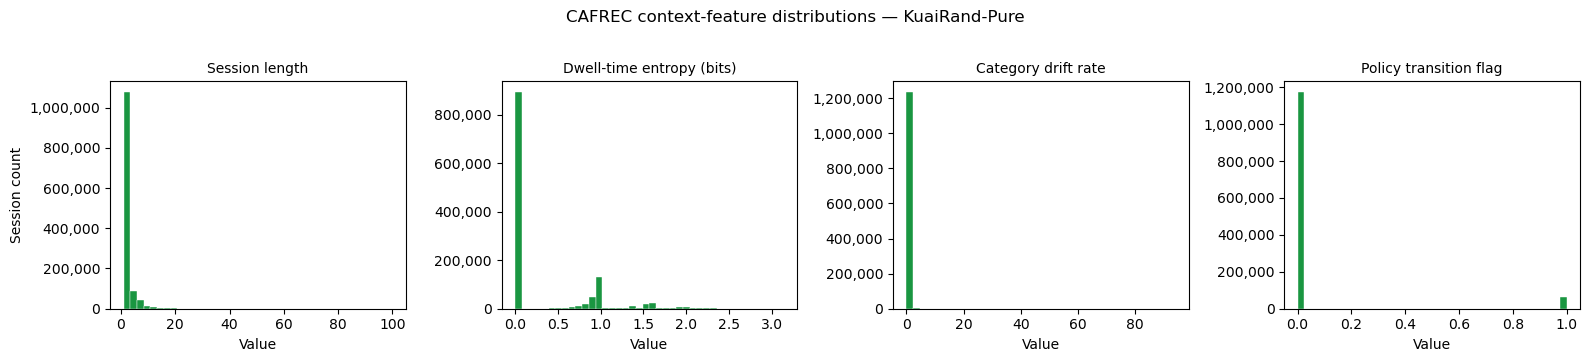

Figure saved: context_feature_distributions.png


In [63]:
# Visualise the four feature distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
titles = [
    "Session length",
    "Dwell-time entropy (bits)",
    "Category drift rate",
    "Policy transition flag",
]
clip_vals = [100, None, None, None]

for ax, col, title, clip in zip(axes, feat_cols, titles, clip_vals):
    data = session_feats[col].clip(upper=clip) if clip else session_feats[col]
    ax.hist(data, bins=40, color="#1a9641", edgecolor="white", linewidth=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Session count" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("CAFREC context-feature distributions — KuaiRand-Pure", y=1.02)
plt.tight_layout()
plt.savefig("context_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: context_feature_distributions.png")


### 7.1  Prevalence audit — `is_hate` and `tab`

Decision inputs for promoting a dissatisfaction signal (`is_hate`) and a
surface signal (`tab`) to context features. This cell **measures only** — it
does not add features. Rule of thumb: promote only if the signal is present
in more than ~5–10% of sessions; below that the column is near-constant and
the gate MLP cannot learn from it. Document the rejected one as a
considered-and-deferred alternative (mirrors the R2d treatment).

In [64]:
hate_row_rate  = logs["is_hate"].mean()
sess_hate_any  = logs.groupby(["user_id", "session_id"])["is_hate"].max().mean()
sess_hate_rate = logs.groupby(["user_id", "session_id"])["is_hate"].mean()

print("--- is_hate prevalence ---")
print(f"  Row-level hate rate          : {hate_row_rate:.5f}  ({int(logs['is_hate'].sum()):,} rows)")
print(f"  Sessions with >=1 hate event : {sess_hate_any:.5f}")
print("  Per-session hate-rate (>0) describe:")
print(sess_hate_rate[sess_hate_rate > 0].describe().round(4).to_string())

sess_tab_nunique = logs.groupby(["user_id", "session_id"])["tab"].nunique()
multi_tab_frac   = (sess_tab_nunique > 1).mean()
logs["_tab_prev"]   = logs.groupby(["user_id", "session_id"])["tab"].shift(1)
tab_change_rate     = ((logs["tab"] != logs["_tab_prev"]) & logs["_tab_prev"].notna()).mean()
logs.drop(columns=["_tab_prev"], inplace=True)

print("\n--- tab (surface) prevalence ---")
print("  Distinct tabs per session describe:")
print(sess_tab_nunique.describe().round(3).to_string())
print(f"  Sessions touching >1 tab     : {multi_tab_frac:.5f}")
print(f"  Row-level tab-change rate    : {tab_change_rate:.5f}")

--- is_hate prevalence ---
  Row-level hate rate          : 0.00079  (2,061 rows)
  Sessions with >=1 hate event : 0.00136
  Per-session hate-rate (>0) describe:
count    1683.0000
mean        0.5409
std         0.3509
min         0.0127
25%         0.2500
50%         0.5000
75%         1.0000
max         1.0000

--- tab (surface) prevalence ---
  Distinct tabs per session describe:
count    1239179.000
mean           1.051
std            0.241
min            1.000
25%            1.000
50%            1.000
75%            1.000
max            5.000
  Sessions touching >1 tab     : 0.04614
  Row-level tab-change rate    : 0.03346


### 7.2  Prefix-causal context features (leakage fix) + inter-session gap

Under leave-one-out, the gate that produces the recommendation for row *t*
must read only the **session prefix** — rows strictly before *t* in the same
session. The full-session aggregates in the original feature cell leak the
held-out target. Every feature below is an **expanding window** over
`(user_id, session_id)`, shifted by one so row *t* sees only rows
`[session_start .. t-1]`. The per-row vector is exactly `x_ctx` for the gate
when that row is the prediction target.

`inter_session_gap_log` is the one new feature (return recency): time since
the user's previous session, known at session start, so it is prefix-safe.
First session per user has no predecessor — imputed with the median log-gap
and flagged via `is_first_session` (optional cold-start indicator; drop it to
stay at 5 features).

In [65]:
t0 = time.perf_counter()

grp  = logs.groupby(["user_id", "session_id"], sort=False)
keys = [logs["user_id"], logs["session_id"]]

# (1) prefix_session_len: interactions seen BEFORE row t (cumcount is 0-indexed)
logs["prefix_session_len"] = grp.cumcount().astype("int32")

# (2) prefix_dwell_entropy: base-2 Shannon entropy of the dwell-bin histogram
#     over the prefix. Explicit one-hot -> expanding cumsum -> shift(1).
N_BINS = 10
dwell_bin = pd.cut(logs["dwell_ratio"].clip(lower=0, upper=1),
                   bins=N_BINS, labels=False, include_lowest=True).to_numpy()
onehot = np.zeros((len(logs), N_BINS), dtype="float32")
ok = ~np.isnan(dwell_bin)
onehot[ok, dwell_bin[ok].astype(int)] = 1.0
onehot = pd.DataFrame(onehot, index=logs.index, columns=[f"b_{i}" for i in range(N_BINS)])
prefix_counts = (onehot.groupby(keys, sort=False).cumsum()
                       .groupby(keys, sort=False).shift(1).fillna(0.0))
tot = prefix_counts.sum(axis=1).to_numpy()
with np.errstate(divide="ignore", invalid="ignore"):
    p    = prefix_counts.to_numpy() / tot[:, None]
    ent  = -np.sum(p * np.where(p > 0, np.log2(p), 0.0), axis=1)
ent[tot == 0] = 0.0
logs["prefix_dwell_entropy"] = np.abs(ent).astype("float32")   # abs() kills -0.0

# (3) prefix_category_drift: category changes in the prefix / prefix transitions.
#     notna guards on BOTH current and previous avoid phantom drift on null tags.
cat_prev = grp["category_id"].shift(1)
drift_ev = ((logs["category_id"] != cat_prev)
            & cat_prev.notna() & logs["category_id"].notna()).astype("float32")
prefix_drift = (drift_ev.groupby(keys, sort=False).cumsum()
                        .groupby(keys, sort=False).shift(1).fillna(0.0))
denom = (logs["prefix_session_len"] - 1).clip(lower=1)
logs["prefix_category_drift"] = (prefix_drift / denom).astype("float32")

# (4) prefix_policy_flag: did an is_rand transition occur anywhere in the prefix?
prefix_pol = (logs["policy_transition"].astype("float32")
              .groupby(keys, sort=False).cumsum()
              .groupby(keys, sort=False).shift(1).fillna(0.0))
logs["prefix_policy_flag"] = (prefix_pol > 0).astype("int8")

# (5) inter_session_gap_log: NEW. log1p(ms since previous session). Prefix-safe.
sb = (logs.groupby(["user_id", "session_id"], sort=False)["time_ms"]
          .agg(sess_start="first", sess_end="last").reset_index())
sb["prev_end"] = sb.groupby("user_id")["sess_end"].shift(1)
sb["gap_ms"]   = sb["sess_start"] - sb["prev_end"]
gap_log = np.log1p(sb["gap_ms"].clip(lower=0))
sb["inter_session_gap_log"] = gap_log.fillna(gap_log.median()).astype("float32")
sb["is_first_session"]      = sb["gap_ms"].isna().astype("int8")
logs = logs.merge(sb[["user_id", "session_id", "inter_session_gap_log", "is_first_session"]],
                  on=["user_id", "session_id"], how="left")

print(f"Prefix-causal features computed in {time.perf_counter()-t0:.1f}s")
print(logs[["prefix_session_len", "prefix_dwell_entropy", "prefix_category_drift",
            "prefix_policy_flag", "inter_session_gap_log", "is_first_session"]]
      .describe().round(4).to_string())

Prefix-causal features computed in 4.5s
       prefix_session_len  prefix_dwell_entropy  prefix_category_drift  prefix_policy_flag  inter_session_gap_log  is_first_session
count        2.622668e+06          2.622668e+06           2.622668e+06        2.622668e+06           2.622668e+06      2.622668e+06
mean         2.105300e+00          2.773000e-01           2.989000e-01        4.400000e-02           1.651830e+01      1.710000e-02
std          4.656300e+00          5.388000e-01           4.443000e-01        2.051000e-01           1.379700e+00      1.297000e-01
min          0.000000e+00          0.000000e+00           0.000000e+00        0.000000e+00           1.440330e+01      0.000000e+00
25%          0.000000e+00          0.000000e+00           0.000000e+00        0.000000e+00           1.531820e+01      0.000000e+00
50%          1.000000e+00          0.000000e+00           0.000000e+00        0.000000e+00           1.645130e+01      0.000000e+00
75%          2.000000e+00          0

### 7.3  Leave-one-out split + standardization

Scaler statistics (mean/std) are fit on **training rows only** — every
interaction except each user's last two (penultimate = val, last = test).
Fitting on the full set would leak the val/test distribution into the gate
input. The unbounded count is log-transformed before scaling; binary flags
are passed through untouched. The fitted params are persisted to JSON so the
modelling stage reuses identical scaling (never re-fit downstream).

In [70]:
DATA_DIR = globals().get("DATA_DIR", Path("data"))
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Per-user chronological rank (logs already sorted by user_id, time_ms)
rank_desc = logs.groupby("user_id").cumcount(ascending=False)   # 0 = last interaction
logs["split"] = np.select([rank_desc == 0, rank_desc == 1],
                           ["test", "val"], default="train")
print("Split row counts:")
print(logs["split"].value_counts().to_string())

# log-transform the count (idempotent: new column, original untouched)
logs["prefix_session_len_log"] = np.log1p(logs["prefix_session_len"]).astype("float32")

CONTINUOUS = ["prefix_session_len_log", "prefix_dwell_entropy",
              "prefix_category_drift", "inter_session_gap_log"]
BINARY     = ["prefix_policy_flag", "is_first_session"]   # is_first_session optional

# Leave-one-out split over ORGANIC rows only (is_rand == 0). Random-policy
# impressions are researcher interventions, not organic engagement (per the
# T1.1 decision record), so they are never held out as a target — they stay
# in the sequence as 'context', feeding the prefix features and the policy flag.
organic = logs["is_rand"] == 0
logs["split"] = "context"
org_rank = logs[organic].groupby("user_id").cumcount(ascending=False)   # 0 = last organic
logs.loc[organic, "split"] = np.where(org_rank == 0, "test",
                              np.where(org_rank == 1, "val", "train"))
print("Split row counts:")
print(logs["split"].value_counts().to_string())

train = logs["split"] == "train"
mu = logs.loc[train, CONTINUOUS].mean()
sd = logs.loc[train, CONTINUOUS].std(ddof=0).replace(0, 1.0)
for c in CONTINUOUS:
    logs[c + "_z"] = ((logs[c] - mu[c]) / sd[c]).astype("float32")

with open(DATA_DIR / "ctx_scaler_params.json", "w") as f:
    json.dump({"features": CONTINUOUS, "mean": mu.tolist(),
               "std": sd.tolist(), "fit_rows": int(train.sum())}, f, indent=2)

CTX_COLS = [c + "_z" for c in CONTINUOUS] + BINARY
ctx_features = logs[["user_id", "session_id", "video_id", "time_ms", "split"] + CTX_COLS].copy()
ctx_features.to_parquet(DATA_DIR / "context_features.parquet", index=False)

print(f"\nx_ctx dimension : {len(CTX_COLS)}  -> {CTX_COLS}")
print(f"Written         : {DATA_DIR / 'context_features.parquet'}")
print("Scaled summary (train split):")
print(ctx_features.loc[ctx_features.split == 'train', CTX_COLS].describe().round(3).to_string())

Split row counts:
split
train    2568098
val        27285
test       27285
Split row counts:
split
train      1382790
context    1186059
test         27077
val          26742

x_ctx dimension : 6  -> ['prefix_session_len_log_z', 'prefix_dwell_entropy_z', 'prefix_category_drift_z', 'inter_session_gap_log_z', 'prefix_policy_flag', 'is_first_session']
Written         : data\context_features.parquet
Scaled summary (train split):
       prefix_session_len_log_z  prefix_dwell_entropy_z  prefix_category_drift_z  inter_session_gap_log_z  prefix_policy_flag  is_first_session
count               1382790.000             1382790.000              1382790.000              1382790.000          1382790.00       1382790.000
mean                     -0.000                   0.000                    0.000                    0.000                0.01             0.031
std                       1.007                   0.995                    1.002                    1.000                0.10             0

In [67]:
# --- 7.4  Leakage & sanity assertions -------------------------------------
first = logs.groupby(["user_id", "session_id"], sort=False).head(1)
assert (first["prefix_session_len"] == 0).all(),        "session-start prefix not empty"
assert (first["prefix_dwell_entropy"].abs() < 1e-6).all(), "entropy leak at session start"
assert (first["prefix_category_drift"].abs() < 1e-6).all(), "drift leak at session start"
assert (first["prefix_policy_flag"] == 0).all(),        "policy leak at session start"

# Spot-check one held-out target: its features must come from its prefix only.
u = logs.loc[logs.split == "test", "user_id"].iloc[0]
ur  = logs[logs.user_id == u].sort_values("time_ms")
tgt = ur.iloc[-1]
exp = len(ur[ur.session_id == tgt.session_id].iloc[:-1])   # prefix length within target session
assert tgt["prefix_session_len"] == exp, (tgt["prefix_session_len"], exp)
print(f"User {u} test target: prefix_len {tgt['prefix_session_len']} == expected {exp}")
print("All leakage assertions passed.")

User 0 test target: prefix_len 2 == expected 2
All leakage assertions passed.


---
## 8  Reconciliation against Expected Distribution

The project plan (Table I) was written for KuaiSAR. The table below reconciles KuaiRand-Pure statistics against KuaiSAR reference figures.

| Statistic | KuaiSAR (plan) | KuaiRand-Pure (this run) | Notes |
|---|---|---|---|
| Users | 25,877 | 27,285 | Comparable scale |
| Items (rec) | 2,281,034 | 7,551 (Pure item pool) | Switch to KuaiRand-1K/27K for full-scale eval |
| Recommendation actions | 7,493,101 | see printed output | Standard rows (`is_rand=0`) only |
| Search actions | 3,171,231 | 0 | `is_rand` flag used as structural replacement |
| Sparse cohort count | TBC Block 1 | computed in Cell 6 | Confirmed |
| Dense cohort count | TBC Block 1 | computed in Cell 6 | Confirmed |

**Version recommendation for T1.2 onwards:** Use **KuaiRand-1K** (4.3 GB) or **KuaiRand-27K** (46 GB) for full model training. The schema and feature-engineering pipeline in this notebook is dataset-agnostic — only the download path and file suffix need changing.


In [68]:
# Final reconciliation summary
total_std  = int((logs.is_rand == 0).sum())
total_rand = int((logs.is_rand == 1).sum())

print("=" * 64)
print("  CAFREC T1.1 Block-1 Reconciliation Summary")
print("=" * 64)
print(f"  Dataset              : KuaiRand-Pure (all 3 log files)")
print(f"  Date range           : {logs.date.min()} to {logs.date.max()}")
print(f"  Total interactions   : {len(logs):>12,}")
print(f"    Standard (is_rand=0): {total_std:>12,}")
print(f"    Random   (is_rand=1): {total_rand:>12,}")
print(f"  Unique users         : {logs.user_id.nunique():>12,}")
print(f"  Unique videos        : {logs.video_id.nunique():>12,}")
print(f"  Total sessions       : {logs.session_id.nunique():>12,}")
print(f"  Sparse users (< {SPARSE_THRESHOLD})   : {n_sparse:>12,}  ({100*n_sparse/n_total:.1f}%)")
print(f"  Dense  users (>={SPARSE_THRESHOLD})   : {n_dense:>12,}  ({100*n_dense/n_total:.1f}%)")
print()
print("  CAFREC Context-Feature -> KuaiRand Column Mapping:")
print(f"    session_length          <- len(session_id group via time_ms 30-min gap)")
print(f"    dwell_time_entropy      <- entropy(play_time_ms / duration_ms) per session")
print(f"    category_drift_rate     <- tag_id change rate per session")
print(f"    search_to_rec_flag      <- policy_transition_flag (is_rand transitions)")
print("=" * 64)


  CAFREC T1.1 Block-1 Reconciliation Summary
  Dataset              : KuaiRand-Pure (all 3 log files)
  Date range           : 20220409 to 20220508
  Total interactions   :    2,622,668
    Standard (is_rand=0):    1,436,609
    Random   (is_rand=1):    1,186,059
  Unique users         :       27,285
  Unique videos        :        7,583
  Total sessions       :    1,211,895
  Sparse users (< 20)   :        7,395  (27.3%)
  Dense  users (>=20)   :       19,682  (72.7%)

  CAFREC Context-Feature -> KuaiRand Column Mapping:
    session_length          <- len(session_id group via time_ms 30-min gap)
    dwell_time_entropy      <- entropy(play_time_ms / duration_ms) per session
    category_drift_rate     <- tag_id change rate per session
    search_to_rec_flag      <- policy_transition_flag (is_rand transitions)


---
## 9  Persist Artefacts

Three files are written to `data/` for downstream Block-1 tasks:

| File | Content | Consumed by |
|------|---------|-------------|
| `logs_sessioned.parquet` | Full interaction log with `session_id`, `category_id`, `policy_transition`, `dwell_ratio` | T1.2 baseline reproduction, T2.1 context features |
| `session_features.parquet` | One row per session with all four CAFREC context features | T2.1 directly |
| `cohort_labels.parquet` | Per-user cohort assignment (sparse / dense) | T3.2 stratified evaluation |


In [69]:
OUT_DIR = Path("data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Sessioned interaction log
log_out = OUT_DIR / "logs_sessioned.parquet"
logs.to_parquet(log_out, index=False, compression="snappy")
print(f"Saved: {log_out}   ({log_out.stat().st_size / 1e6:.1f} MB)")

# 2. Per-session feature tensors
feat_out = OUT_DIR / "session_features.parquet"
session_feats.to_parquet(feat_out, index=False, compression="snappy")
print(f"Saved: {feat_out}   ({feat_out.stat().st_size / 1e6:.1f} MB)")

# 3. Cohort labels
cohort_df = pd.DataFrame({
    "user_id":          rec_counts.index,
    "rec_action_count": rec_counts.values,
    "cohort":           np.where(rec_counts.values < SPARSE_THRESHOLD, "sparse", "dense"),
})
cohort_out = OUT_DIR / "cohort_labels.parquet"
cohort_df.to_parquet(cohort_out, index=False, compression="snappy")
print(f"Saved: {cohort_out}   ({cohort_out.stat().st_size / 1e6:.1f} MB)")


Saved: data\logs_sessioned.parquet   (89.0 MB)
Saved: data\session_features.parquet   (8.4 MB)
Saved: data\cohort_labels.parquet   (0.2 MB)
